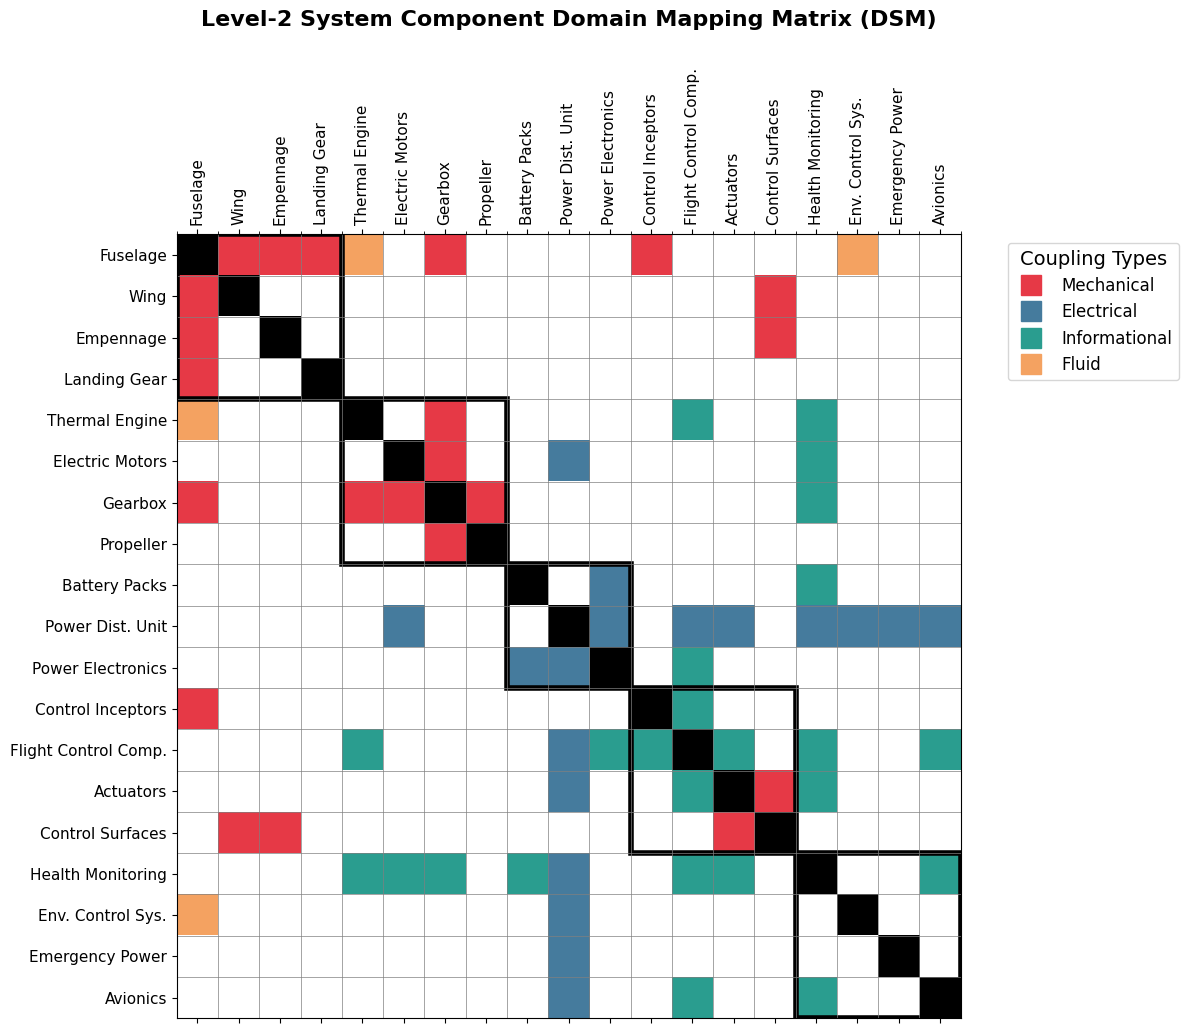

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
from matplotlib.colors import ListedColormap

# 1. Define the Level-2 Components grouped by Level-1 Subsystems
components = [
    # Airframe
    "Fuselage", "Wing", "Empennage", "Landing Gear",
    # Propulsion System
    "Thermal Engine", "Electric Motors", "Gearbox", "Propeller",
    # Electrical & Energy System
    "Battery Packs", "Power Dist. Unit", "Power Electronics",
    # Flight & Control System
    "Control Inceptors", "Flight Control Comp.", "Actuators", "Control Surfaces",
    # Safety & Support System
    "Health Monitoring", "Env. Control Sys.", "Emergency Power", "Avionics"
]

n = len(components)
matrix = np.zeros((n, n), dtype=int)

# Helper function to add symmetric connections
def add_conn(c1, c2, ctype):
    i, j = components.index(c1), components.index(c2)
    matrix[i, j] = ctype
    matrix[j, i] = ctype

# 2. Map the Connections
# Connection Types: 1=Mechanical (Red), 2=Electrical (Blue), 3=Informational (Green), 4=Fluid (Yellow)

# --- Mechanical (Red) ---
add_conn("Fuselage", "Wing", 1)
add_conn("Fuselage", "Empennage", 1)
add_conn("Fuselage", "Landing Gear", 1)
add_conn("Fuselage", "Gearbox", 1)
add_conn("Wing", "Control Surfaces", 1)
add_conn("Empennage", "Control Surfaces", 1)
add_conn("Thermal Engine", "Gearbox", 1)
add_conn("Electric Motors", "Gearbox", 1)
add_conn("Gearbox", "Propeller", 1)
add_conn("Actuators", "Control Surfaces", 1)
add_conn("Control Inceptors", "Fuselage", 1)

# --- Electrical (Blue) ---
add_conn("Battery Packs", "Power Electronics", 2)
add_conn("Power Electronics", "Power Dist. Unit", 2)
for c in ["Electric Motors", "Flight Control Comp.", "Actuators", "Health Monitoring", "Env. Control Sys.", "Avionics"]:
    add_conn("Power Dist. Unit", c, 2)
add_conn("Emergency Power", "Power Dist. Unit", 2)

# --- Informational (Green) ---
add_conn("Control Inceptors", "Flight Control Comp.", 3)
add_conn("Avionics", "Flight Control Comp.", 3)
add_conn("Flight Control Comp.", "Actuators", 3)
add_conn("Flight Control Comp.", "Thermal Engine", 3)
add_conn("Flight Control Comp.", "Power Electronics", 3)
for c in ["Thermal Engine", "Electric Motors", "Gearbox", "Battery Packs", "Flight Control Comp.", "Actuators", "Avionics"]:
    add_conn("Health Monitoring", c, 3)

# --- Fluid (Yellow) ---
# Note: matrix overwrites previous values. We apply fluid last so it sits on top of mechanical if they overlap.
add_conn("Fuselage", "Thermal Engine", 4) # Fuel routing
add_conn("Env. Control Sys.", "Fuselage", 4) # Cabin Air & Pressurization

# Ensure diagonal elements are marked (Black)
for i in range(n):
    matrix[i, i] = 5

# 3. Plotting the DSM
fig, ax = plt.subplots(figsize=(12, 12))
cmap = ListedColormap(['white', '#E63946', '#457B9D', '#2A9D8F', '#F4A261', 'black']) # Softer professional colors
cax = ax.matshow(matrix, cmap=cmap, vmin=0, vmax=5)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(components, rotation=90, fontsize=11)
ax.set_yticklabels(components, fontsize=11)

ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

# Draw black rectangles around Level-1 Subsystems
subsystems = [
    ("Airframe", 0, 4),
    ("Propulsion", 4, 4),
    ("Energy", 8, 3),
    ("Flight Control", 11, 4),
    ("Safety & Support", 15, 4)
]

for name, start, length in subsystems:
    rect = patches.Rectangle((start - 0.5, start - 0.5), length, length, linewidth=4, edgecolor='black', facecolor='none')
    ax.add_patch(rect)

# Add Legend
colors = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261']
labels = ['Mechanical', 'Electrical', 'Informational', 'Fluid']
handles = [mlines.Line2D([], [], color=c, marker='s', linestyle='None', markersize=15, label=l) for c, l in zip(colors, labels)]
plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=12, title="Coupling Types", title_fontsize=14)

plt.title("Level-2 System Component Domain Mapping Matrix (DSM)", pad=30, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

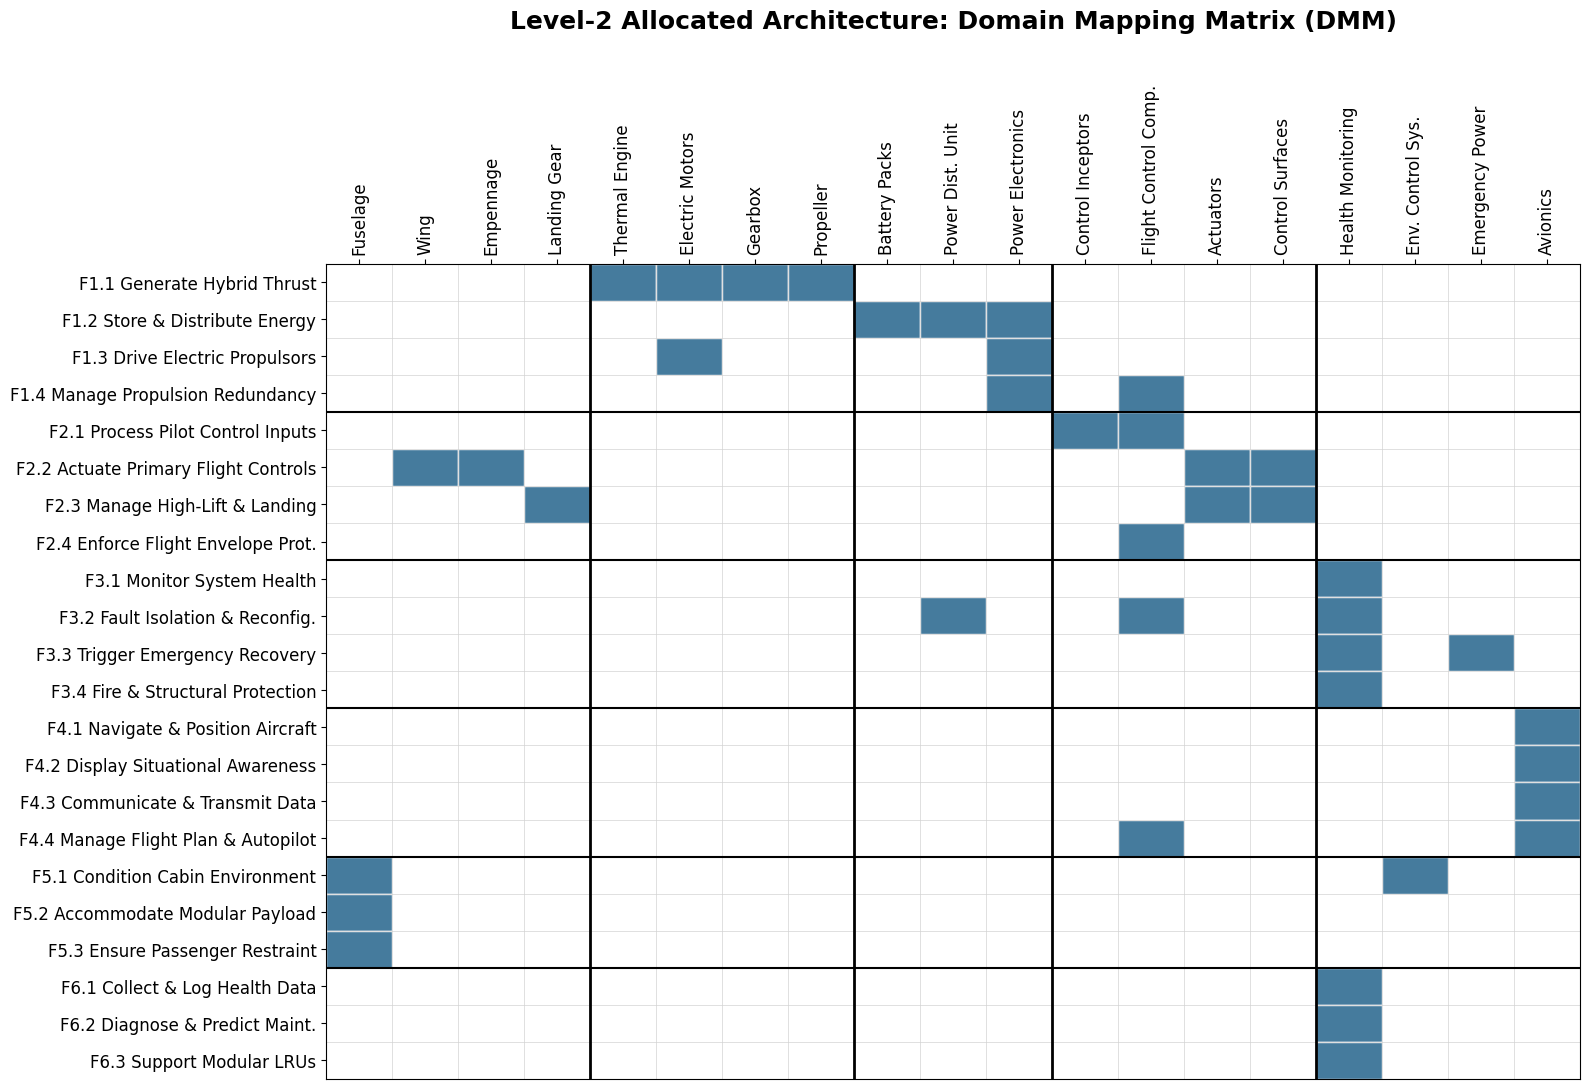

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Define Data - 22 Functions exactly as listed by teammates
functions = [
    "F1.1 Generate Hybrid Thrust", "F1.2 Store & Distribute Energy", "F1.3 Drive Electric Propulsors",
    "F1.4 Manage Propulsion Redundancy", "F2.1 Process Pilot Control Inputs", "F2.2 Actuate Primary Flight Controls",
    "F2.3 Manage High-Lift & Landing", "F2.4 Enforce Flight Envelope Prot.", "F3.1 Monitor System Health",
    "F3.2 Fault Isolation & Reconfig.", "F3.3 Trigger Emergency Recovery", "F3.4 Fire & Structural Protection",
    "F4.1 Navigate & Position Aircraft", "F4.2 Display Situational Awareness", "F4.3 Communicate & Transmit Data",
    "F4.4 Manage Flight Plan & Autopilot", "F5.1 Condition Cabin Environment", "F5.2 Accommodate Modular Payload",
    "F5.3 Ensure Passenger Restraint", "F6.1 Collect & Log Health Data", "F6.2 Diagnose & Predict Maint.",
    "F6.3 Support Modular LRUs"
]

# 2. Define Data - 19 Components exactly as listed by teammates
components = [
    "Fuselage", "Wing", "Empennage", "Landing Gear",
    "Thermal Engine", "Electric Motors", "Gearbox", "Propeller",
    "Battery Packs", "Power Dist. Unit", "Power Electronics",
    "Control Inceptors", "Flight Control Comp.", "Actuators", "Control Surfaces",
    "Health Monitoring", "Env. Control Sys.", "Emergency Power", "Avionics"
]

# 3. Exhaustive Mappings (Row Index, Component Name)
mappings = [
    (0, "Thermal Engine"), (0, "Electric Motors"), (0, "Gearbox"), (0, "Propeller"),
    (1, "Battery Packs"), (1, "Power Dist. Unit"), (1, "Power Electronics"),
    (2, "Electric Motors"), (2, "Power Electronics"),
    (3, "Flight Control Comp."), (3, "Power Electronics"),
    (4, "Control Inceptors"), (4, "Flight Control Comp."),
    (5, "Actuators"), (5, "Control Surfaces"), (5, "Wing"), (5, "Empennage"),
    (6, "Actuators"), (6, "Control Surfaces"), (6, "Landing Gear"),
    (7, "Flight Control Comp."),
    (8, "Health Monitoring"),
    (9, "Health Monitoring"), (9, "Power Dist. Unit"), (9, "Flight Control Comp."),
    (10, "Health Monitoring"), (10, "Emergency Power"),
    (11, "Health Monitoring"),
    (12, "Avionics"),
    (13, "Avionics"),
    (14, "Avionics"),
    (15, "Avionics"), (15, "Flight Control Comp."),
    (16, "Env. Control Sys."), (16, "Fuselage"),
    (17, "Fuselage"),
    (18, "Fuselage"),
    (19, "Health Monitoring"),
    (20, "Health Monitoring"),
    (21, "Health Monitoring")
]

n_rows = len(functions)
n_cols = len(components)
fig, ax = plt.subplots(figsize=(16, 11))

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.invert_yaxis()

for x in range(n_cols + 1):
    ax.axvline(x, color='lightgray', linewidth=0.5)
for y in range(n_rows + 1):
    ax.axhline(y, color='lightgray', linewidth=0.5)

comp_idx = {name: i for i, name in enumerate(components)}

for func_i, comp_name in mappings:
    if comp_name in comp_idx:
        col_j = comp_idx[comp_name]
        rect = patches.Rectangle((col_j, func_i), 1, 1, facecolor='#457B9D', edgecolor='white')
        ax.add_patch(rect)

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_xticklabels(components, rotation=90, fontsize=12)
ax.set_yticklabels(functions, fontsize=12)
ax.xaxis.tick_top()

# Group separators for Subsystems (Columns) and Functions (Rows)
row_separators = [4, 8, 12, 16, 19]
col_separators = [4, 8, 11, 15]

for y in row_separators:
    ax.axhline(y, color='black', linewidth=1.5)
for x in col_separators:
    ax.axvline(x, color='black', linewidth=2)

plt.title("Level-2 Allocated Architecture: Domain Mapping Matrix (DMM)", pad=40, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()
